# Exercise 1: Fully Connected and Convolutional Neural Networks

**Group Members (please state here)**:
1.   Yi-Hui Fan
2.   Avik Das
3.   

**Please submit as groups of no more than three students.**

---

**Note**: For this assignment, it is **highly recommended that you use a GPU** to speed up the training process, especially for the convolutional neural network (CNN) model. Training on a CPU can be significantly slower, particularly for models with many parameters. If you don't have access to a GPU, you can use free resources like Kaggle Notebooks or Google Colab, which  offer free GPU support.





## 1. Load and Explore the MNIST Dataset



### 1.1 Import Libraries

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers

2026-04-27 08:01:43.550456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777276903.755995      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777276903.814246      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777276904.250718      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777276904.250802      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777276904.250805      55 computation_placer.cc:177] computation placer alr

### 1.2 Load Dataset

Load the MNIST dataset, a collection of 28x28 grayscale images representing handwritten digits from 0 to 9, using [TensorFlow's `datasets` module](https://www.tensorflow.org/datasets). Visualize the dataset by displaying a grid of 16 randomly selected images along with their labels.

In [2]:
# load MNIST dataset from TensorFlow
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1777276930.927050      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Shuffling /root/tensorflow_datasets/mnist/incomplete.AZ3KZE_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.AZ3KZE_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


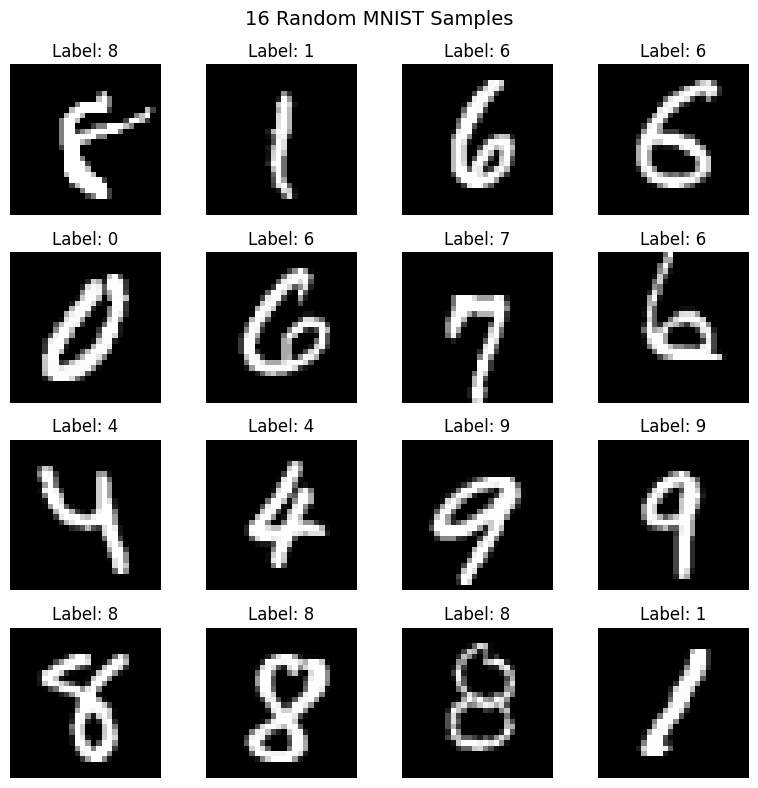

In [3]:
# visualize 16 randomly selected images along with their labels
import matplotlib.pyplot as plt
import numpy as np

samples = list(ds_train.shuffle(1000).take(16))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, (image, label) in enumerate(samples):
    ax = axes[i // 4][i % 4]
    ax.imshow(image.numpy().squeeze(), cmap='gray')
    ax.set_title(f'Label: {label.numpy()}')
    ax.axis('off')

plt.suptitle('16 Random MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

### 1.3 Data Preprocessing

Preprocess the data by normalizing the pixel values to the range [0, 1].

In [4]:
# normalize the pixel values to the range [0, 1]
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(normalize)
ds_test = ds_test.map(normalize)

## 2. Define and Train a Fully Connected Neural Network (FCN)

Using [TensorFlow's keras API](https://keras.io/api/), define a fully connected neural network (FCN) with the following architecture:

* **Input Layer**: A flattened version of the 28x28 input images (i.e., shape (784,)).
* **Hidden Layers**: Two dense layers, each with 128 neurons and ReLU activation.
* **Output Layer**: A dense layer with 10 neurons (one per digit) and softmax activation for classification.

Train the model using the Adam optimizer with a learning rate of 0.001, cross-entropy loss, and track accuracy. Train for 10 epochs with a batch size of 32. Evaluate the test accuracy and analyze the training process using the learning curves (loss and accuracy).




In [5]:
# define model layer-by-layer using TensorFlow/keras
model_fcn = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_fcn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_fcn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# train the model
history_fcn = model_fcn.fit(
    ds_train.batch(32),
    epochs=10,
    validation_data=ds_test.batch(32)
)

Epoch 1/10


I0000 00:00:1777276973.721845     127 service.cc:152] XLA service 0x7e98c800d030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777276973.721889     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777276973.964099     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


  53/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4841 - loss: 1.7273

I0000 00:00:1777276974.607237     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8830 - loss: 0.3980 - val_accuracy: 0.9628 - val_loss: 0.1216
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9695 - loss: 0.1014 - val_accuracy: 0.9738 - val_loss: 0.0846
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9794 - loss: 0.0660 - val_accuracy: 0.9757 - val_loss: 0.0833
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0484 - val_accuracy: 0.9757 - val_loss: 0.0814
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9883 - loss: 0.0374 - val_accuracy: 0.9765 - val_loss: 0.0828
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9891 - loss: 0.0332 - val_accuracy: 0.9741 - val_loss: 0.0975
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9917 - loss: 0.0240 - val_accuracy: 0.9736 - val_loss: 0.0996
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9939 - loss: 0.0200 - val_accurac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0966
Test Accuracy: 0.9767
Test Loss: 0.1031


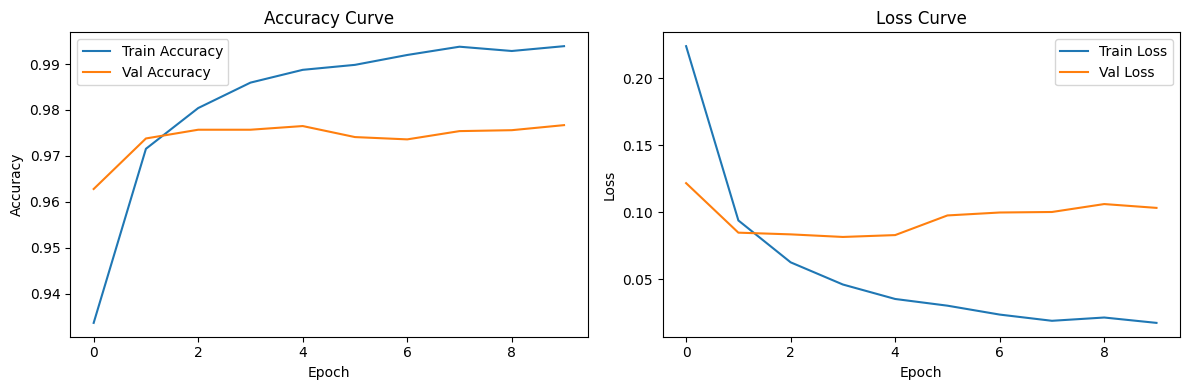

In [7]:
# evaluate the model
test_loss, test_acc = model_fcn.evaluate(ds_test.batch(32))
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy curve
axes[0].plot(history_fcn.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_fcn.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# loss curve
axes[1].plot(history_fcn.history['loss'], label='Train Loss')
axes[1].plot(history_fcn.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Define and Train a Convolutional Neural Network (CNN)

Create a convolutional neural network (CNN) for MNIST classification using TensorFlow's keras API with the following architecture:

* **Input Layer**: Accepts 28x28 grayscale images with shape (28, 28, 1).
* **Conv2D Layer 1**: 32 filters, kernel size (3, 3), ReLU activation.
* **MaxPooling2D Layer**: Pool size (2, 2) for spatial down-sampling.
* **Conv2D Layer 2**: 64 filters, kernel size (3, 3), ReLU activation.
* **MaxPooling2D Layer**: Pool size (2, 2).
* **Flatten Layer**: Converts the 2D feature map into a 1D vector.
* **Dense Layer**: 128 neurons with ReLU activation.
* **Output Layer**: A dense layer with 10 neurons (softmax activation).

Train this CNN using the same setup as in Task 2. Adjust the learning rate, epoch count, and batch size if necessary. After training, compare its test accuracy and training process to the FCN from Task 2.

In [8]:
# define model layer-by-layer using TensorFlow/keras
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# train the model
history_cnn = model_cnn.fit(
    ds_train.batch(32),
    epochs=10,
    validation_data=ds_test.batch(32)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9066 - loss: 0.2951 - val_accuracy: 0.9836 - val_loss: 0.0505
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9853 - loss: 0.0484 - val_accuracy: 0.9850 - val_loss: 0.0485
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9906 - loss: 0.0321 - val_accuracy: 0.9889 - val_loss: 0.0355
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9931 - loss: 0.0224 - val_accuracy: 0.9876 - val_loss: 0.0425
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9941 - loss: 0.0177 - val_accuracy: 0.9869 - val_loss: 0.0453
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9961 - loss: 0.0134 - val_accuracy: 0.9886 - val_loss: 0.0389
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9970 - loss: 0.0090 - val_accuracy: 0.9909 - val_loss: 0.0414
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9975 - loss: 0.0073 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9917 - loss: 0.0373
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0966
CNN  - Test Accuracy: 0.9910 | Test Loss: 0.0415
FCN  - Test Accuracy: 0.9767 | Test Loss: 0.1031


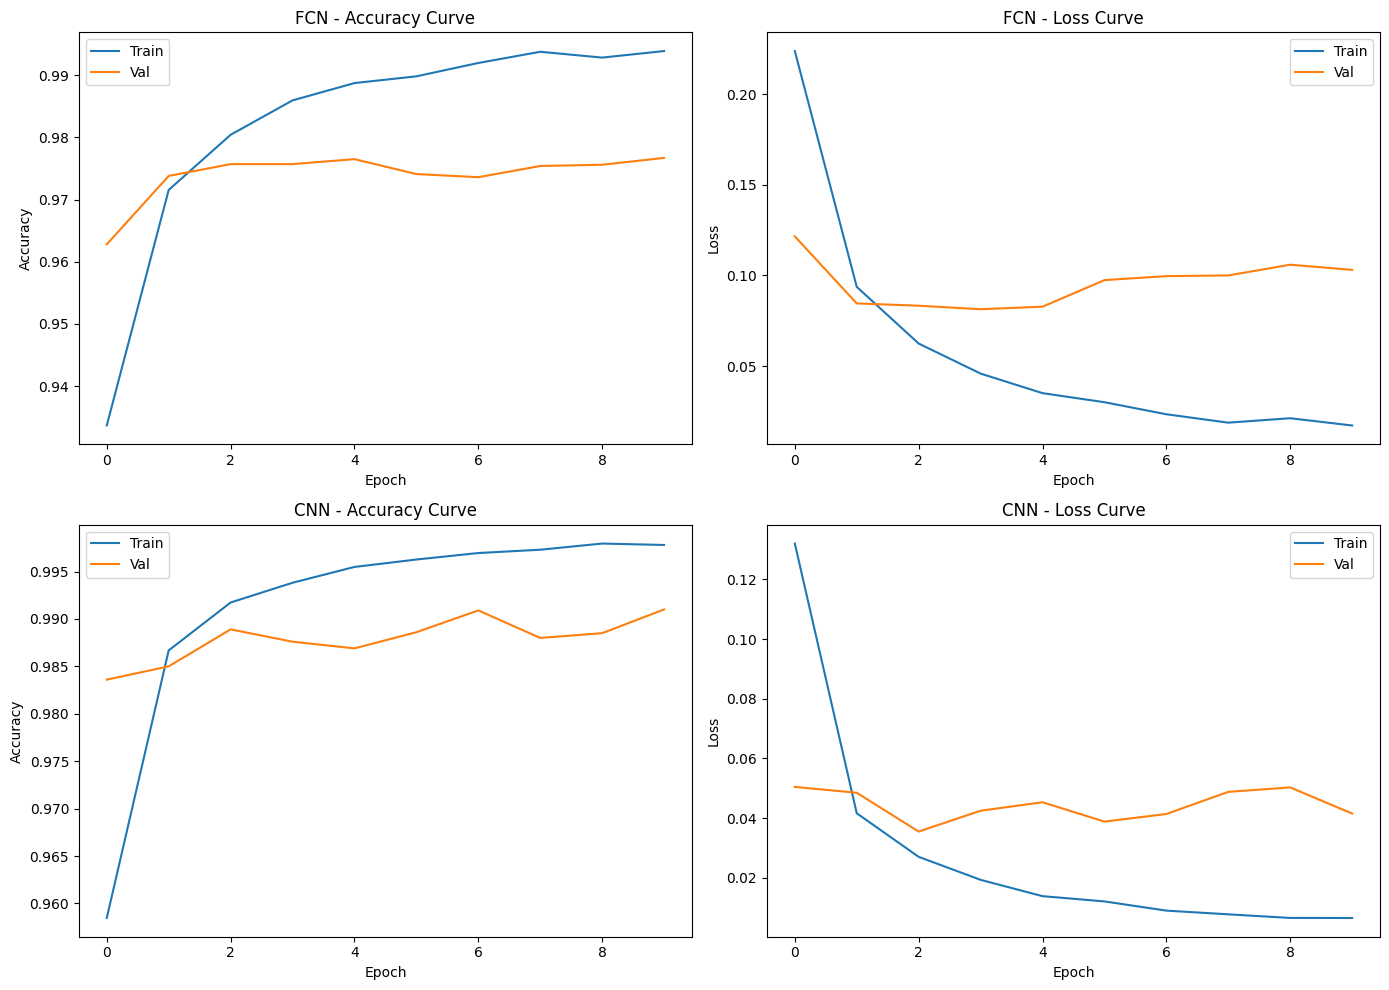

In [10]:
# evaluate the model and compare it to the FCN from task 2
cnn_loss, cnn_acc = model_cnn.evaluate(ds_test.batch(32))
fcn_loss, fcn_acc = model_fcn.evaluate(ds_test.batch(32))

print(f'CNN  - Test Accuracy: {cnn_acc:.4f} | Test Loss: {cnn_loss:.4f}')
print(f'FCN  - Test Accuracy: {fcn_acc:.4f} | Test Loss: {fcn_loss:.4f}')

# plot learning curves comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FCN accuracy
axes[0][0].plot(history_fcn.history['accuracy'], label='Train')
axes[0][0].plot(history_fcn.history['val_accuracy'], label='Val')
axes[0][0].set_title('FCN - Accuracy Curve')
axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('Accuracy')
axes[0][0].legend()

# FCN loss
axes[0][1].plot(history_fcn.history['loss'], label='Train')
axes[0][1].plot(history_fcn.history['val_loss'], label='Val')
axes[0][1].set_title('FCN - Loss Curve')
axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('Loss')
axes[0][1].legend()

# CNN accuracy
axes[1][0].plot(history_cnn.history['accuracy'], label='Train')
axes[1][0].plot(history_cnn.history['val_accuracy'], label='Val')
axes[1][0].set_title('CNN - Accuracy Curve')
axes[1][0].set_xlabel('Epoch')
axes[1][0].set_ylabel('Accuracy')
axes[1][0].legend()

# CNN loss
axes[1][1].plot(history_cnn.history['loss'], label='Train')
axes[1][1].plot(history_cnn.history['val_loss'], label='Val')
axes[1][1].set_title('CNN - Loss Curve')
axes[1][1].set_xlabel('Epoch')
axes[1][1].set_ylabel('Loss')
axes[1][1].legend()

plt.tight_layout()
plt.show()